## **Import Necessary Libraries and Modules**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

SEED = 42

## **Load and Prepare Data**

In [ ]:
df = pd.read_csv("../encoded_dataset.csv")

display(df.head())

,timestamp,age,gender,college,year_of_study,gpa_range,currently_employed,leisure_hours,self_study_hours,study_environment,...,difficult_to_maintain,data_quality_check,comfort_or_convenience,peers_consider_normal,control_over_habit,sooner_next_month,delay_until_deadline,focus_frequency,delay_unenjoyable_assignments,referrer
0,2026-05-14 00:28:00,19,1,1,1,5,0,2.0,4.0,1.0,...,5,3,6,5,5,4,5,5.0,4.0,Nguyễn Cảnh Kỳ
1,2026-05-14 00:30:30,19,2,2,1,5,1,2.0,8.0,1.0,...,1,3,1,3,4,7,2,4.0,5.0,Đặng Tuấn Kiệt
2,2026-05-14 00:30:32,19,1,1,1,4,0,4.0,3.0,2.0,...,2,3,3,3,4,4,2,3.0,4.0,Đặng Tuấn Kiệt
3,2026-05-14 00:32:25,19,1,1,1,4,0,5.0,4.0,1.0,...,4,3,7,3,4,1,4,5.0,6.0,Nguyễn Trọng Nhân
4,2026-05-14 00:33:32,23,1,3,1,5,0,4.0,1.0,1.0,...,6,3,6,6,5,4,6,5.0,6.0,Bill


In [ ]:
df.columns

Index(['timestamp', 'age', 'gender', 'college', 'year_of_study', 'gpa_range',
       'currently_employed', 'leisure_hours', 'self_study_hours',
       'study_environment', 'sleep_hours', 'impact_on_learning_progress',
       'far_away_deadlines', 'study_plan', 'start_early_when_necessary',
       'difficult_to_maintain', 'data_quality_check', 'comfort_or_convenience',
       'peers_consider_normal', 'control_over_habit', 'sooner_next_month',
       'delay_until_deadline', 'focus_frequency',
       'delay_unenjoyable_assignments', 'referrer'],
      dtype='str')

## **Feature and Binary Target Selection**

In [ ]:
# ------------------- Binary Target Selection -----------------------
# >= 4 is 1 (procrastinate), < 4 is 0 (does not procrastinate)
target_feature = "delay_until_deadline"
y = (df[target_feature] >= 5).astype(int)


# ------------------- Feature Selection -----------------------------
drop_features = [
    "delay_until_deadline",
    "timestamp",
    "referrer",
    "data_quality_check",
    "delay_unenjoyable_assignments",
]

# Filter out a list of 20 candidate features
candidate_features = df.drop(columns=drop_features).columns

# Assess the correlation of each feature with the target variable
features_correlation = []
for feature in candidate_features:
    correlation = df[feature].corr(df[target_feature])
    features_correlation.append(
        {
            "Feature": feature,
            "Correlation": correlation,
            "Absolute Correlation": abs(correlation),
        }
    )

corr_df = pd.DataFrame(features_correlation).sort_values(
    by="Absolute Correlation", ascending=False
)
display(corr_df)

# Choose the top 15 features
top_15_features = corr_df.iloc[:15, 0]
display(top_15_features)

X = df[top_15_features]

,Feature,Correlation,Absolute Correlation
11,far_away_deadlines,0.471036,0.471036
15,comfort_or_convenience,0.456476,0.456476
14,difficult_to_maintain,0.384220,0.384220
6,leisure_hours,0.359945,0.359945
16,peers_consider_normal,0.325998,0.325998
7,self_study_hours,-0.315510,0.315510
17,control_over_habit,-0.260267,0.260267
10,impact_on_learning_progress,0.258609,0.258609
19,focus_frequency,-0.218111,0.218111
13,start_early_when_necessary,-0.187439,0.187439


11             far_away_deadlines
15         comfort_or_convenience
14          difficult_to_maintain
6                   leisure_hours
16          peers_consider_normal
7                self_study_hours
17             control_over_habit
10    impact_on_learning_progress
19                focus_frequency
13     start_early_when_necessary
4                       gpa_range
12                     study_plan
18              sooner_next_month
3                   year_of_study
2                         college
Name: Feature, dtype: str

## **Train/Test Split and Feature Scaling**

In [ ]:
# ─────────────────────────────────────────────
# 2. Perform stratified train-test split
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

print(f"Number of training samples is: {X_train.shape[0]}")
print(f"Number of testing_samples is: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Number of training samples is: 96
Number of testing_samples is: 97


## **Logistic Regression**

### **Baseline Models**

In [ ]:
def predict_maximize_gmean(model, X, y_true):

    # 1. Get predicted probabilities for the positive class (column 1)
    y_scores = model.predict_proba(X)[:, 1]

    # Scenario A: We are calculating the optimal threshold dynamically (e.g., on a validation set)
    if y_true is not None:
        # Calculate True Positive Rate (Sensitivity) and False Positive Rate across thresholds
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)

        # Specificity is 1 - False Positive Rate
        specificity = 1 - fpr

        # Calculate G-Mean: sqrt(Sensitivity * Specificity)
        gmeans = np.sqrt(tpr * specificity)

        # Locate the index of the maximum G-Mean
        best_idx = np.argmax(gmeans)
        optimal_threshold = thresholds[best_idx]

        # Handle edge case where roc_curve arbitrarily sets the first threshold above 1.0
        if optimal_threshold > 1.0:
            optimal_threshold = 1.0

    # 2. Apply the optimal threshold to binarize predictions
    y_pred = (y_scores >= optimal_threshold).astype(int)

    return y_pred, optimal_threshold

In [ ]:
logistic_regression_baseline = LogisticRegression(max_iter=1000, solver="liblinear")
logistic_regression_baseline.fit(X_train, y_train)
# Baseline AUC
print(
    f"Train AUC: {roc_auc_score(y_train, logistic_regression_baseline.predict_proba(X_train)[:, 1])}"
)
print(
    f"Test AUC: {roc_auc_score(y_test, logistic_regression_baseline.predict_proba(X_test)[:, 1])}"
)
y_pred, threshold = predict_maximize_gmean(logistic_regression_baseline, X_test, y_test)
print(f"Confusion matrix (test), threshold = {threshold}:")
print(confusion_matrix(y_test, y_pred))

Train AUC: 0.8791304347826087
Test AUC: 0.7612958226768969
Confusion matrix (test), threshold = 0.5408051324004971:
[[38 13]
 [15 31]]


In [ ]:
logistic_regression_scaled = LogisticRegression(max_iter=1000, solver="liblinear")
logistic_regression_scaled.fit(X_train_sc, y_train)
# Scaled AUC
print(
    f"Train AUC: {roc_auc_score(y_train, logistic_regression_scaled.predict_proba(X_train_sc)[:, 1])}"
)
print(
    f"Test AUC: {roc_auc_score(y_test, logistic_regression_scaled.predict_proba(X_test_sc)[:, 1])}"
)
y_pred, threshold = predict_maximize_gmean(
    logistic_regression_scaled, X_test_sc, y_test
)
print(f"Confusion matrix (test), threshold = {threshold}:")
print(confusion_matrix(y_test, y_pred))

Train AUC: 0.8817391304347826
Test AUC: 0.7817561807331629
Confusion matrix (test), threshold = 0.5260801927787374:
[[39 12]
 [14 32]]


### **Hyperparameter Tuning**

In [ ]:
def train_logistic(**kwargs):
    model = LogisticRegression(max_iter=1000, **kwargs)
    model.fit(X_train_sc, y_train)
    return model

The optimum regularization strength c is: 1e-05


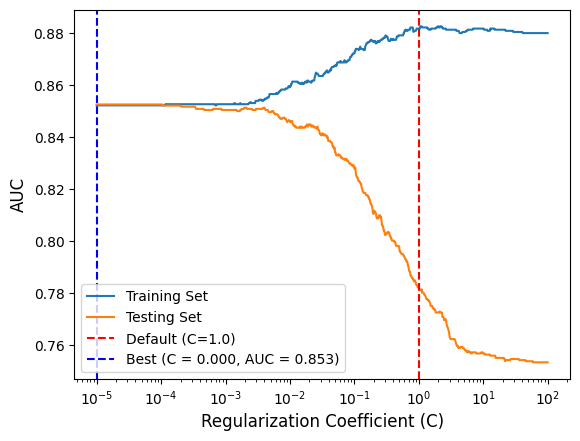

In [ ]:
# Vary regularization strength for L2 regularization
auc_df = pd.DataFrame(columns=["C", "Training Set", "Testing Set"])
for C in np.logspace(-5, 2, 1000):
    model = train_logistic(C=C, solver="liblinear")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]

best_auc_idx = auc_df["Testing Set"].idxmax()
best_c_l2 = auc_df.loc[best_auc_idx, "C"]
best_auc = auc_df.loc[best_auc_idx, "Testing Set"]
print(f"The optimum regularization strength c is: {best_c_l2}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True)
ax.axvline(x=1.0, color="red", linestyle="--", label="Default (C=1.0)")
ax.axvline(
    x=best_c_l2,
    color="blue",
    linestyle="--",
    label=f"Best (C = {best_c_l2:.3f}, AUC = {best_auc:.3f})",
)
ax.set_xlabel("Regularization Coefficient (C)", fontsize=12)
ax.set_ylabel("AUC", fontsize=12)
ax.legend()
plt.savefig("../figures/l2_logistic_auc.pdf", bbox_inches="tight")

The optimum regularization strength c is: 0.33076497807442423


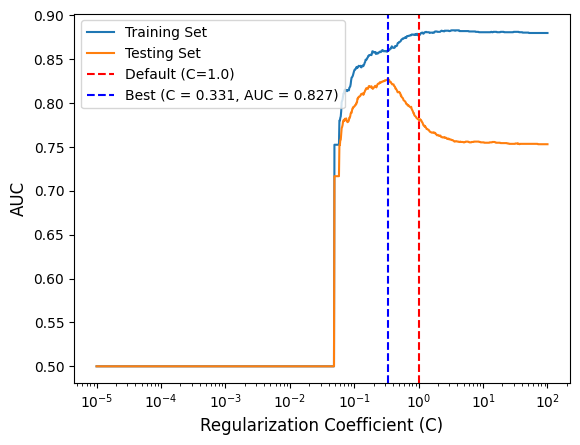

In [ ]:
# Vary regularization strength for L2 regularization
auc_df = pd.DataFrame(columns=["C", "Training Set", "Testing Set"])
for C in np.logspace(-5, 2, 1000):
    model = train_logistic(C=C, l1_ratio=1, solver="liblinear")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]

best_auc_idx = auc_df["Testing Set"].idxmax()
best_c_l1 = auc_df.loc[best_auc_idx, "C"]
best_auc = auc_df.loc[best_auc_idx, "Testing Set"]
print(f"The optimum regularization strength c is: {best_c_l1}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True)
ax.axvline(x=1.0, color="red", linestyle="--", label="Default (C=1.0)")
ax.axvline(
    x=best_c_l1,
    color="blue",
    linestyle="--",
    label=f"Best (C = {best_c_l1:.3f}, AUC = {best_auc:.3f})",
)
ax.set_xlabel("Regularization Coefficient (C)", fontsize=12)
ax.set_ylabel("AUC", fontsize=12)
ax.legend()
plt.savefig("../figures/l1_logistic_auc.pdf", bbox_inches="tight")

## **SVM**

### **Baseline Models**

In [ ]:
# ─────────────────────────────────────────────
# 1. Baseline SVM Model
# ─────────────────────────────────────────────

svm_baseline = SVC(probability=True, random_state=SEED)
svm_baseline.fit(X_train, y_train)

train_auc_score = roc_auc_score(y_train, svm_baseline.predict_proba(X_train)[:, 1])
test_auc_score = roc_auc_score(y_test, svm_baseline.predict_proba(X_test)[:, 1])

print(f"Train AUC: {train_auc_score:.4f}")
print(f"Test AUC:  {test_auc_score:.4f}")

NameError: name 'SVC' is not defined

In [ ]:
# ─────────────────────────────────────────────
# 2. Baseline Scaled SVM Model
# ─────────────────────────────────────────────

svm_scaled_baseline = SVC(probability=True, random_state=SEED)
svm_scaled_baseline.fit(X_train_sc, y_train)

train_auc_scaled = roc_auc_score(
    y_train, svm_scaled_baseline.predict_proba(X_train_sc)[:, 1]
)
test_auc_scaled = roc_auc_score(
    y_test, svm_scaled_baseline.predict_proba(X_test_sc)[:, 1]
)

print(f"Train AUC: {train_auc_scaled:.4f}")
print(f"Test AUC:  {test_auc_scaled:.4f}")

Train AUC: 0.9739
Test AUC:  0.8124


### **Hyperparameter Tuning**

In [ ]:
def train_svm(**kwargs):
    model = SVC(probability=True, random_state=SEED, **kwargs)
    model.fit(X_train_sc, y_train)
    return model

The optimum regularization strength c is: 0.005991769669310619


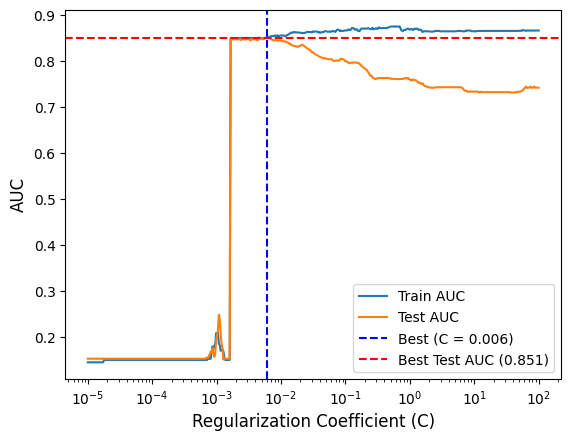

In [ ]:
# Vary regularization strength for Linear kernel
auc_df = pd.DataFrame(columns=["C", "Train AUC", "Test AUC"])
for C in np.logspace(-5, 2, 500):
    model = train_svm(C=C, kernel="linear", gamma="scale")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]


best_auc_idx = auc_df["Test AUC"].idxmax()
best_auc = auc_df.loc[best_auc_idx, "Test AUC"]
best_c_linear_svm = auc_df.loc[best_auc_idx, "C"]
print(f"The optimum regularization strength c is: {best_c_linear_svm}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True)
# ax.axvline(x=1.0, color='red', linestyle='--', label='Default (C=1.0)')
ax.axvline(
    x=best_c_linear_svm,
    color="blue",
    linestyle="--",
    label=f"Best (C = {best_c_linear_svm:.3f})",
)
ax.axhline(
    y=best_auc, color="red", linestyle="--", label=f"Best Test AUC ({best_auc:.3f})"
)
ax.set_xlabel("Regularization Coefficient (C)", fontsize=12)
ax.set_ylabel("AUC", fontsize=12)
ax.legend()
plt.savefig("../figures/linear_svm_auc.pdf", bbox_inches="tight")

The optimum regularization strength c is: 0.1838776980082327


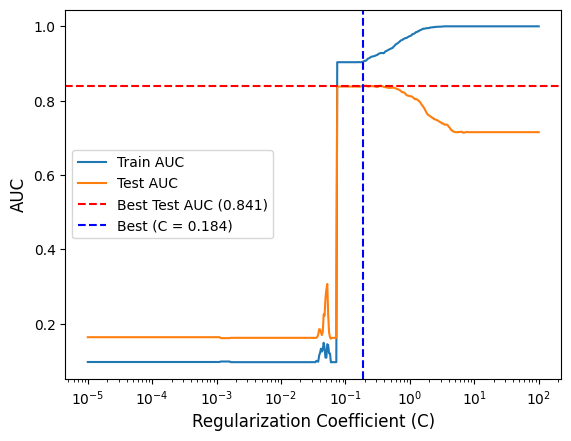

In [ ]:
# Vary regularization strength for RBF kernel
auc_df = pd.DataFrame(columns=["C", "Train AUC", "Test AUC"])
for C in np.logspace(-5, 2, 500):
    model = train_svm(C=C, kernel="rbf", gamma="scale")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]


best_auc_idx = auc_df["Test AUC"].idxmax()
best_auc = auc_df.loc[best_auc_idx, "Test AUC"]
best_c_rbf_svm = auc_df.loc[best_auc_idx, "C"]
print(f"The optimum regularization strength c is: {best_c_rbf_svm}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True)
ax.axhline(
    y=best_auc, color="red", linestyle="--", label=f"Best Test AUC ({best_auc:.3f})"
)
ax.axvline(
    x=best_c_rbf_svm,
    color="blue",
    linestyle="--",
    label=f"Best (C = {best_c_rbf_svm:.3f})",
)
ax.set_xlabel("Regularization Coefficient (C)", fontsize=12)
ax.set_ylabel("AUC", fontsize=12)
ax.legend()
plt.savefig("../figures/rbf_svm_auc.pdf", bbox_inches="tight")

## **Final Evaluation**

### **Find optimal threshold for models (maximizing geometric mean of sensitivity and specificity)**

In [ ]:
best_logreg_model = train_logistic(l1_ratio=0, C=best_c_l2, solver="liblinear")
best_svm_model = train_svm(kernel="linear", C=best_c_linear_svm, gamma="scale")

# logreg_y_proba = best_logreg_model.predict_proba(X_test_sc)[:,1]
# logreg_pred = (logreg_y_proba > 0.5).astype(int)

# svm_y_proba = best_svm_model.predict_proba(X_test_sc)[:,1]
# svm_pred = (svm_y_proba > 0.5).astype(int)

logreg_pred_optimal, logreg_threshold_optimal = predict_maximize_gmean(
    best_logreg_model, X_test_sc, y_test
)
svm_pred_optimal, svm_threshold_optimal = predict_maximize_gmean(
    best_svm_model, X_test_sc, y_test
)


print(f"Optimal threshold for Logistic Regression is {logreg_threshold_optimal}")
print(f"Optimal threshold for SVM is {svm_threshold_optimal}")

Optimal threshold for Logistic Regression is 0.49997830609075283
Optimal threshold for SVM is 0.3922872203824586


In [ ]:
# ─────────────────────────────────────────────
# 4. Metrics
# ─────────────────────────────────────────────
def get_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'─' * 40}")
    print(f"  {label} Metrics")
    print(f"{'─' * 40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

### **Evaluate models with optimal threshold**

In [ ]:
# =====================================================
# FINAL COMPARISON: BEST LOGREG vs BEST SVM
# Using Optimized Thresholds
# =====================================================

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON (Test Set with Optimized Thresholds)")
print("=" * 70)

# Get metrics for Logistic Regression
logreg_acc, logreg_prec, logreg_rec, logreg_f1 = get_metrics(
    y_test,
    logreg_pred_optimal,
    f"Logistic Regression (L2, C={best_c_l2:.6f}, threshold={logreg_threshold_optimal:.4f})",
)

# Get metrics for SVM
svm_acc, svm_prec, svm_rec, svm_f1 = get_metrics(
    y_test,
    svm_pred_optimal,
    f"SVM (Linear, C={best_c_linear_svm:.6f}, threshold={svm_threshold_optimal:.4f})",
)

# Step 5: Comparison Table
print(f"\n{'=' * 70}")
print("METRICS COMPARISON TABLE")
print(f"{'=' * 70}\n")

comparison_df = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "SVM (Linear)"],
        "Accuracy": [f"{logreg_acc:.4f}", f"{svm_acc:.4f}"],
        "Precision": [f"{logreg_prec:.4f}", f"{svm_prec:.4f}"],
        "Recall": [f"{logreg_rec:.4f}", f"{svm_rec:.4f}"],
        "F1-Score": [f"{logreg_f1:.4f}", f"{svm_f1:.4f}"],
    }
)

print(comparison_df.to_string(index=False))

# Step 6: Determine Winner
print(f"\n{'=' * 70}")
print("WINNER ANALYSIS")
print(f"{'=' * 70}\n")

if svm_f1 > logreg_f1:
    print(f"✓ SVM (Linear) is the BETTER model")
    print(
        f"  - F1-Score: {svm_f1:.4f} vs {logreg_f1:.4f} (+{(svm_f1 - logreg_f1):.4f})"
    )
else:
    print(f"✓ Logistic Regression is the BETTER model")
    print(
        f"  - F1-Score: {logreg_f1:.4f} vs {svm_f1:.4f} (+{(logreg_f1 - svm_f1):.4f})"
    )

print(f"\nOther metrics:")
print(f"  Accuracy:  LR={logreg_acc:.4f}, SVM={svm_acc:.4f}")
print(f"  Precision: LR={logreg_prec:.4f}, SVM={svm_prec:.4f}")
print(f"  Recall:    LR={logreg_rec:.4f}, SVM={svm_rec:.4f}")

# Step 7: Confusion Matrices
print(f"\n{'=' * 70}")
print("CONFUSION MATRICES")
print(f"{'=' * 70}\n")

print("Logistic Regression:")
print(confusion_matrix(y_test, logreg_pred_optimal))

print("\nSVM (Linear):")
print(confusion_matrix(y_test, svm_pred_optimal))


FINAL MODEL COMPARISON (Test Set with Optimized Thresholds)

────────────────────────────────────────
  Logistic Regression (L2, C=0.000010, threshold=0.5000) Metrics
────────────────────────────────────────
  Accuracy  : 0.7938
  Precision : 0.7500
  Recall    : 0.8478
  F1-Score  : 0.7959

────────────────────────────────────────
  SVM (Linear, C=0.005992, threshold=0.3923) Metrics
────────────────────────────────────────
  Accuracy  : 0.7938
  Precision : 0.7500
  Recall    : 0.8478
  F1-Score  : 0.7959

METRICS COMPARISON TABLE

              Model Accuracy Precision Recall F1-Score
Logistic Regression   0.7938    0.7500 0.8478   0.7959
       SVM (Linear)   0.7938    0.7500 0.8478   0.7959

WINNER ANALYSIS

✓ Logistic Regression is the BETTER model
  - F1-Score: 0.7959 vs 0.7959 (+0.0000)

Other metrics:
  Accuracy:  LR=0.7938, SVM=0.7938
  Precision: LR=0.7500, SVM=0.7500
  Recall:    LR=0.8478, SVM=0.8478

CONFUSION MATRICES

Logistic Regression:
[[38 13]
 [ 7 39]]

SVM (Linear